# Exploratory Data Analysis (EDA) - Assignment 1

**Student Name:** Elior Nassi  
**Student ID:** 314806704  
**Course:** Introduction to Data Science  
**Lecturer:** Dr. Ori Itai  
**Tutor:** Hanit Ohayon Hadad  
**Submission Date:** 2.8.2026  
**Submission Format:** Individual  

---

## 1. Project Introduction

This assignment presents a comprehensive Exploratory Data Analysis (EDA) of a large-scale global maritime anchorage dataset.

The analysis examines the dataset as the result of a measurement and collection process rather than treating it as unquestionable ground truth. Its main objectives are to evaluate data quality, identify missing or suspicious values, examine geographical and categorical distributions, detect statistical outliers, study relationships between variables, and assess limitations that may affect future engineering or statistical applications.

The dataset contains geographical coordinates, country codes, anchorage descriptions, distances from shore, drift-radius measurements, data-source labels, and docking indicators. These attributes make it suitable for investigating the spatial and structural properties of maritime anchorage locations.

The analysis does not interpret the dataset as a chronological vessel-traffic log because it does not include timestamps, vessel identifiers, routes, speeds, or event sequences.

## 2. Dataset Source and Context Description

- **Dataset source:** The dataset was downloaded from Kaggle and was provided as a CSV file named `ocean_data.csv`.
- **Dataset page:** https://www.kaggle.com/datasets/anarjinary/global-anchorages
- **Dataset publisher: A. Narjinary (Kaggle contributor) The dataset description states that it contains more than 165,000 global anchorage locations where vessels congregate. According to the publisher, the anchorage information is updated periodically using publicly available Global Fishing Watch anchorage data together with several additional maritime reference sources.
- **Download date:** The dataset was downloaded for this assignment during July 2026.
- **Original collector:** The organization responsible for collecting and maintaining the original records is not clearly documented in the available file. This absence of source documentation is an important limitation because the sampling procedure, measurement equipment, update frequency, and quality-control process cannot be independently evaluated.
- **Collection purpose:** Based on the column structure, the dataset appears to describe global maritime anchorage locations and their geographical, administrative, and spatial characteristics. However, the original collection purpose cannot be confirmed without additional source documentation.
- **Domain context:** The table contains geographical coordinates, anchorage names, country codes, distance-from-shore measurements, drift-radius values, source labels, and docking indicators. These attributes make the dataset relevant for exploratory spatial analysis, maritime infrastructure analysis, navigation-support systems, and preliminary maritime risk assessment.
- **Interpretation limitation:** The dataset does not contain vessel identifiers, timestamps, speeds, routes, measurement dates, or event sequences. Therefore, it should not be interpreted as a chronological vessel-traffic dataset or used to infer temporal movement patterns.
- **Personal domain connection:** The dataset is relevant to engineering and data analysis because it combines continuous measurements, geographical coordinates, categorical classifications, identifiers, and potentially imperfect operational metadata.
- **Assignment requirement limitation:** The dataset satisfies the minimum requirements of at least 1,000 rows and at least 10 columns and includes both numerical and categorical variables. However, it does not contain an explicit temporal variable. Therefore, time-dependent analysis cannot be performed without joining an additional reliable data source.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure notebook visualizations
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# Configure clear numerical display in DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Define and load the dataset
DATA_PATH = "ocean_data.csv"
ocean_data = pd.read_csv(DATA_PATH, low_memory=False)

# File-level metadata
file_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)

print("--- Dataset File Metadata ---")
print(f"File name: {os.path.basename(DATA_PATH)}")
print("File format: CSV")
print(f"File size: {file_size_mb:.2f} MB")

# Dataset dimensions and structure
print("\n--- Dataset Dimensions ---")
print(f"Number of rows: {ocean_data.shape[0]:,}")
print(f"Number of columns: {ocean_data.shape[1]}")

print("\n--- Column Names ---")
print(ocean_data.columns.tolist())

print("\n--- Data Types and Non-Null Counts ---")
ocean_data.info()

print("\n--- First Five Rows ---")
display(ocean_data.head())

--- Dataset File Metadata ---
File name: ocean_data.csv
File format: CSV
File size: 18.62 MB

--- Dataset Dimensions ---
Number of rows: 166,482
Number of columns: 10

--- Column Names ---
['s2id', 'lat', 'lon', 'label', 'sublabel', 'label_source', 'iso3', 'distance_from_shore_m', 'drift_radius', 'dock']

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 166482 entries, 0 to 166481
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   s2id                   166482 non-null  str    
 1   lat                    166482 non-null  float64
 2   lon                    166482 non-null  float64
 3   label                  166482 non-null  str    
 4   sublabel               160198 non-null  str    
 5   label_source           166482 non-null  str    
 6   iso3                   166482 non-null  str    
 7   distance_from_shore_m  166457 non-null  float64
 8   drift_radius       

,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock
0,477eac73,45.47,12.45,ITA-196,CA' SAVIO,anchorage_overrides,ITA,0.00,0.06,True
1,3442a529,25.18,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.15,True
2,3442a52f,25.18,121.41,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.06,True
3,3442a4d5,25.19,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.17,False
4,3442a4d7,25.18,121.40,TAMSUI FISH WHARF,TAN-SHUI,anchorage_overrides,TWN,0.00,0.18,False


## 3. Data Structural and Meta-Analysis (15%)

### 3.1 File Analysis

- **File format:** The dataset is stored as a Comma-Separated Values (`.csv`) file.
- **File size:** The physical file size is approximately 18.62 MB.
- **Creation date:** The original dataset source does not provide a verified creation date. Therefore, the temporal freshness of the records cannot be confirmed.
- **Dataset purpose:** The table describes global maritime anchorage locations and associated geographical and administrative attributes.
- **Temporal limitation:** The dataset does not contain an explicit date or timestamp column. Consequently, temporal trends, seasonality, and time-based changes cannot be evaluated from this file alone.

The absence of a verified creation date and temporal variables is an important limitation rather than information that should be assumed.

### 3.2 Dataset Structure

The dataset contains exactly **166,482 rows** and **10 columns**. It therefore satisfies the assignment requirements regarding the minimum number of rows and columns.

The column names are generally meaningful and suitable for maritime and geospatial analysis:

- `s2id`: A spatial cell identifier associated with the S2 geometry system.
- `lat`: Latitude coordinate in decimal degrees.
- `lon`: Longitude coordinate in decimal degrees.
- `label`: The primary name assigned to an anchorage or maritime location.
- `sublabel`: A more specific or secondary location description.
- `label_source`: The source from which the textual location label was obtained.
- `iso3`: A three-letter country code.
- `distance_from_shore_m`: Distance from the location to the shoreline, measured in meters.
- `drift_radius`: A radius associated with the spatial extent or drift area of the anchorage.
- `dock`: An indicator associated with docking status.

The dataset combines numerical and categorical attributes. However, it does not contain a temporal variable.

### 3.3 Collection Purpose and Possible Biases

The table appears to have been created primarily for operational or geographical use rather than as a controlled scientific experiment. Its structure resembles a reference table of anchorage locations rather than a chronological record of individual vessel movements.

Possible biases include:

1. **Geographical coverage bias:** Countries and regions with more complete maritime mapping may be overrepresented.
2. **Source bias:** Location labels may depend on the coverage and conventions of the source systems.
3. **Administrative bias:** Country codes and labels represent administrative classifications that may not perfectly describe real maritime activity.
4. **Temporal uncertainty:** Without a timestamp or verified creation date, it is impossible to determine whether all records represent the same period or how current they are.
5. **Measurement and definition bias:** Variables such as `drift_radius` may have been calculated using source-specific rules that are not documented in the CSV file.

In [2]:
# --- SECTION 4: Data Quality and Completeness ---

# Preserve an unchanged copy for auditing and comparison
raw_ocean_data = ocean_data.copy()

# --------------------------------------------------
# 4.1 Missing Values
# --------------------------------------------------
print("--- 4.1 Missing Values Before Treatment ---")

missing_summary = pd.DataFrame(
    {
        "missing_count": raw_ocean_data.isna().sum(),
        "missing_percentage": raw_ocean_data.isna().mean().mul(100),
    }
).sort_values("missing_count", ascending=False)

display(missing_summary)

columns_with_missing_values = missing_summary[
    missing_summary["missing_count"] > 0
]

print(
    "Columns containing missing values: "
    f"{columns_with_missing_values.index.tolist()}"
)

# Examine combinations of missing values across rows
missing_pattern_summary = (
    raw_ocean_data.isna()
    .astype(int)
    .value_counts()
    .rename("row_count")
    .reset_index()
)

missing_pattern_summary["row_percentage"] = (
    missing_pattern_summary["row_count"]
    .div(len(raw_ocean_data))
    .mul(100)
)

print("\n--- Most Common Missing-Value Patterns ---")
display(missing_pattern_summary.head(10))

# Examine whether missingness is associated with the label source
for column_name in columns_with_missing_values.index:
    missing_by_source = (
        raw_ocean_data
        .assign(is_missing=raw_ocean_data[column_name].isna())
        .groupby("label_source", dropna=False)["is_missing"]
        .agg(["count", "sum", "mean"])
        .rename(
            columns={
                "count": "group_size",
                "sum": "missing_count",
                "mean": "missing_rate",
            }
        )
    )

    missing_by_source["missing_percentage"] = (
        missing_by_source["missing_rate"] * 100
    )

    missing_by_source = missing_by_source.sort_values(
        "missing_percentage",
        ascending=False,
    )

    print(
        f"\n--- Missingness in {column_name} "
        "by Label Source ---"
    )

    display(
        missing_by_source[
            [
                "group_size",
                "missing_count",
                "missing_percentage",
            ]
        ]
    )

# Create a cleaned working copy
ocean_data = raw_ocean_data.copy()

# --------------------------------------------------
# Remove impossible geographical coordinates
# --------------------------------------------------
invalid_coordinate_mask = (
    ~ocean_data["lat"].between(-90, 90)
    | ~ocean_data["lon"].between(-180, 180)
)

invalid_coordinate_rows = ocean_data.loc[
    invalid_coordinate_mask,
    ["s2id", "lat", "lon", "label", "iso3"],
].copy()

print("\n--- Invalid Coordinate Rows ---")
print(
    f"Number of invalid coordinate rows: "
    f"{len(invalid_coordinate_rows)}"
)
display(invalid_coordinate_rows)

ocean_data = ocean_data.loc[
    ~invalid_coordinate_mask
].copy()

print(
    "Rows remaining after removing invalid coordinates: "
    f"{len(ocean_data):,}"
)

# --------------------------------------------------
# Missing-value treatment
# --------------------------------------------------
ocean_data["sublabel"] = ocean_data["sublabel"].fillna(
    "Unknown_Sublocation"
)

for numerical_column in [
    "distance_from_shore_m",
    "drift_radius",
]:
    country_medians = (
        ocean_data
        .groupby("iso3")[numerical_column]
        .transform("median")
    )

    ocean_data[numerical_column] = (
        ocean_data[numerical_column]
        .fillna(country_medians)
        .fillna(ocean_data[numerical_column].median())
    )

dock_mapping = {
    True: True,
    False: False,
    "True": True,
    "False": False,
    "true": True,
    "false": False,
    1: True,
    0: False,
    1.0: True,
    0.0: False,
}

normalized_dock = ocean_data["dock"].map(dock_mapping)
dock_mode = normalized_dock.mode(dropna=True).iloc[0]

ocean_data["dock"] = (
    normalized_dock
    .fillna(dock_mode)
    .astype("boolean")
)

print("\n--- Missing Values After Treatment ---")

display(
    pd.DataFrame(
        {
            "missing_count": ocean_data.isna().sum(),
            "missing_percentage": (
                ocean_data.isna().mean().mul(100)
            ),
        }
    )
)

# --------------------------------------------------
# 4.2 Full and Partial Duplicates
# --------------------------------------------------
print("\n--- 4.2 Duplicate Analysis ---")

full_duplicate_count = raw_ocean_data.duplicated().sum()

coordinate_duplicate_mask = raw_ocean_data.duplicated(
    subset=["lat", "lon"],
    keep=False,
)

s2id_duplicate_mask = raw_ocean_data.duplicated(
    subset=["s2id"],
    keep=False,
)

# Normalize labels before checking semantic partial duplicates
normalized_label = (
    raw_ocean_data["label"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True)
)

normalized_sublabel = (
    raw_ocean_data["sublabel"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True)
)

duplicate_check_data = pd.DataFrame(
    {
        "normalized_label": normalized_label,
        "normalized_sublabel": normalized_sublabel,
        "iso3": raw_ocean_data["iso3"],
    }
)

label_country_duplicate_mask = (
    duplicate_check_data.duplicated(
        subset=["normalized_label", "iso3"],
        keep=False,
    )
    & duplicate_check_data["normalized_label"].notna()
)

label_sublabel_country_duplicate_mask = (
    duplicate_check_data.duplicated(
        subset=[
            "normalized_label",
            "normalized_sublabel",
            "iso3",
        ],
        keep=False,
    )
    & duplicate_check_data["normalized_label"].notna()
    & duplicate_check_data["normalized_sublabel"].notna()
)

duplicate_summary = pd.Series(
    {
        "Full duplicate rows": full_duplicate_count,
        "Rows with duplicated latitude and longitude": (
            coordinate_duplicate_mask.sum()
        ),
        "Rows with duplicated s2id": (
            s2id_duplicate_mask.sum()
        ),
        "Rows with duplicated normalized label and country": (
            label_country_duplicate_mask.sum()
        ),
        (
            "Rows with duplicated normalized label, "
            "sublabel and country"
        ): label_sublabel_country_duplicate_mask.sum(),
    },
    name="row_count",
)

display(duplicate_summary.to_frame())

print(
    "\nRepeated labels were not removed automatically because "
    "different maritime locations may legitimately share the "
    "same or a similar name."
)

# --------------------------------------------------
# 4.3 Suspicious, Impossible and Placeholder Values
# --------------------------------------------------
print(
    "\n--- 4.3 Suspicious, Impossible and "
    "Placeholder Values ---"
)

suspicious_value_checks = pd.Series(
    {
        "Latitude below -90": (
            raw_ocean_data["lat"] < -90
        ).sum(),
        "Latitude above 90": (
            raw_ocean_data["lat"] > 90
        ).sum(),
        "Longitude below -180": (
            raw_ocean_data["lon"] < -180
        ).sum(),
        "Longitude above 180": (
            raw_ocean_data["lon"] > 180
        ).sum(),
        "Negative distance from shore": (
            raw_ocean_data["distance_from_shore_m"] < 0
        ).sum(),
        "Negative drift radius": (
            raw_ocean_data["drift_radius"] < 0
        ).sum(),
        "Zero distance from shore": (
            raw_ocean_data["distance_from_shore_m"] == 0
        ).sum(),
        "Zero drift radius": (
            raw_ocean_data["drift_radius"] == 0
        ).sum(),
        "Missing dock values": (
            raw_ocean_data["dock"].isna().sum()
        ),
    },
    name="count",
)

display(suspicious_value_checks.to_frame())

zero_distance_count = (
    raw_ocean_data["distance_from_shore_m"] == 0
).sum()

zero_distance_percentage = (
    zero_distance_count
    / raw_ocean_data["distance_from_shore_m"].notna().sum()
    * 100
)

print(
    "\nZero distance-from-shore values: "
    f"{zero_distance_count:,} "
    f"({zero_distance_percentage:.2f}% of non-missing values)"
)

placeholder_values = {
    "",
    " ",
    "unknown",
    "n/a",
    "na",
    "none",
    "null",
    "-",
    "--",
    "?",
    "999",
    "-999",
}

text_columns = raw_ocean_data.select_dtypes(
    include=["object", "string"]
).columns

placeholder_summary = {}

for column_name in text_columns:
    normalized_values = (
        raw_ocean_data[column_name]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    placeholder_summary[column_name] = (
        normalized_values.isin(placeholder_values).sum()
    )

placeholder_summary = (
    pd.Series(
        placeholder_summary,
        name="placeholder_count",
    )
    .sort_values(ascending=False)
    .to_frame()
)

print("\n--- Placeholder Values in Text Columns ---")
display(placeholder_summary)

print("\nOriginal dock value types:")

display(
    raw_ocean_data["dock"]
    .map(lambda value: type(value).__name__)
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

print("\nOriginal dock values:")

display(
    raw_ocean_data["dock"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

# --------------------------------------------------
# 4.4 Cardinality
# --------------------------------------------------
print("\n--- 4.4 Cardinality Analysis ---")

cardinality_summary = pd.DataFrame(
    {
        "unique_values": raw_ocean_data.nunique(
            dropna=False
        ),
        "unique_percentage": (
            raw_ocean_data.nunique(dropna=False)
            .div(len(raw_ocean_data))
            .mul(100)
        ),
    }
).sort_values(
    "unique_values",
    ascending=False,
)

display(cardinality_summary)

constant_columns = cardinality_summary[
    cardinality_summary["unique_values"] <= 1
].index.tolist()

high_cardinality_columns = cardinality_summary[
    cardinality_summary["unique_percentage"] >= 90
].index.tolist()

print(f"Constant columns: {constant_columns}")

print(
    "High-cardinality columns "
    "(at least 90% unique): "
    f"{high_cardinality_columns}"
)

print(
    "\nLatitude and longitude are continuous geographical "
    "measurements. Their high percentage of unique values is "
    "expected and should not be interpreted in the same way as "
    "high cardinality in a categorical variable."
)

--- 4.1 Missing Values Before Treatment ---


,missing_count,missing_percentage
sublabel,6284,3.77
drift_radius,153,0.09
distance_from_shore_m,25,0.02
dock,20,0.01
lat,0,0.00
s2id,0,0.00
label_source,0,0.00
label,0,0.00
lon,0,0.00
iso3,0,0.00


Columns containing missing values: ['sublabel', 'drift_radius', 'distance_from_shore_m', 'dock']

--- Most Common Missing-Value Patterns ---


,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock,row_count,row_percentage
0,0,0,0,0,0,0,0,0,0,0,160023,96.12
1,0,0,0,0,1,0,0,0,0,0,6282,3.77
2,0,0,0,0,0,0,0,0,1,0,131,0.08
3,0,0,0,0,0,0,0,1,0,0,24,0.01
4,0,0,0,0,0,0,0,0,1,1,20,0.01
5,0,0,0,0,1,0,0,1,1,0,1,0.00
6,0,0,0,0,1,0,0,0,1,0,1,0.00



--- Missingness in sublabel by Label Source ---


...


Original dock values:


,count
dock,
False,87939
True,78523
NaN,20



--- 4.4 Cardinality Analysis ---


,unique_values,unique_percentage
s2id,166482,100.00
lat,166482,100.00
lon,166481,100.00
drift_radius,166330,99.91
sublabel,31151,18.71
label,14618,8.78
distance_from_shore_m,279,0.17
iso3,180,0.11
label_source,6,0.00
dock,3,0.00


Constant columns: []
High-cardinality columns (at least 90% unique): ['s2id', 'lat', 'lon', 'drift_radius']

Latitude and longitude are continuous geographical measurements. Their high percentage of unique values is expected and should not be interpreted in the same way as high cardinality in a categorical variable.


## 4. Data Quality and Completeness Analysis (20%)

### 4.1 Missing Values and Treatment Strategy

The original dataset contains missing values in four columns:

- `sublabel`: 6,284 missing values.
- `drift_radius`: 153 missing values.
- `distance_from_shore_m`: 25 missing values.
- `dock`: 20 missing values.

Missingness is concentrated in specific fields rather than distributed equally across the entire table. This suggests a structured data-collection or annotation pattern rather than a general file-corruption problem.

The available data alone is insufficient to formally prove whether the missingness mechanism is MCAR, MAR, or MNAR. However, the concentration of missing values in descriptive and derived attributes suggests that the values may depend on the source or annotation process.

Treatment decisions:

- Missing `sublabel` values were replaced with `Unknown_Sublocation`. This preserves the rows while explicitly retaining the fact that the more specific label was unavailable.
- Missing numerical values in `distance_from_shore_m` and `drift_radius` were imputed using the median of the corresponding country group. A global median fallback was included for any country group lacking a usable median.
- Missing `dock` values were filled using the mode after normalizing the observed values to a consistent Boolean representation.

These choices are suitable for exploratory analysis, but the imputed values should not be interpreted as directly observed measurements.

### 4.2 Duplicate Analysis

The dataset contains no full duplicate rows.

Partial duplication was evaluated separately using geographical coordinates and the `s2id` spatial identifier. Repeated coordinates are not automatically errors because multiple anchorage records may share a geographical point or represent different labels associated with the same area.

Therefore, partial duplicates should not be removed automatically. They should first be evaluated together with identifiers, labels, and source information.

### 4.3 Suspicious and Impossible Values

The validation identified one record with a longitude greater than 180 degrees. Since valid longitude values must fall between -180 and 180 degrees, this record contains an impossible geographical coordinate.

The invalid record was displayed for auditing and then removed from the cleaned working dataset before subsequent spatial and statistical analyses.

The following validation rules were also evaluated:

- Latitude must be between -90 and 90 degrees.
- Longitude must be between -180 and 180 degrees.
- `distance_from_shore_m` must not be negative.
- `drift_radius` must not be negative.

No negative distance or drift-radius values were detected.

A large number of records have a shore distance of exactly zero. These values are not necessarily errors because an anchorage or dock may be located directly at the shoreline. However, their high frequency may also reflect measurement rounding, a source-specific convention, or a placeholder rule. They were therefore retained but treated as an important interpretation limitation.

The original `dock` column was loaded as an `object` column because it contained Boolean values together with missing values. It was normalized to a consistent nullable Boolean representation before imputation.

### 4.4 Cardinality

Cardinality analysis was used to identify:

- Constant columns with no useful variation.
- Low-cardinality categorical variables.
- High-cardinality identifier or descriptive columns.
- Columns whose number of unique values is close to the total number of rows.

A high-cardinality column is not necessarily problematic. For example, `s2id` is intended to behave as a spatial identifier. However, such columns should usually not be treated directly as ordinary categorical predictors without suitable encoding or feature engineering.

## 5. Univariate Analysis (10%)

### 5.1 Numerical Variable Analysis

The variable `distance_from_shore_m` is strongly right-skewed. Most observations are concentrated relatively close to the shoreline, while a smaller number of observations extend to substantially larger distances.

Because of this asymmetry, the mean is pulled upward by the long right tail and does not represent a typical observation as well as the median. The median, IQR, and MAD are therefore more suitable robust measures for describing the center and spread of this variable.

Three one-dimensional outlier-detection methods were applied:

1. **Standard Z-score:** Identifies observations located more than three standard deviations from the mean. It assumes that the mean and standard deviation adequately describe the distribution and may be affected by strong skewness.
2. **IQR rule:** Identifies observations outside the interval defined by `Q1 - 1.5 × IQR` and `Q3 + 1.5 × IQR`. It is less sensitive to extreme observations.
3. **Modified Z-score:** Uses the median and MAD rather than the mean and standard deviation, making it more robust for skewed distributions.

The methods produce different outlier counts because they rely on different assumptions. In this dataset, a large distance from shore may represent a valid anchorage rather than an error. Therefore, observations should not be removed solely because they are statistically unusual.

### 5.2 Categorical Variable Analysis

The `iso3` variable has an imbalanced distribution. A relatively small number of country codes account for a large proportion of the observations, while many country codes have low frequencies.

The analysis reports:

- The most common category and its percentage.
- The top 10 most frequent categories.
- The minimum number of country codes required to cover at least 80% of the observations.
- The exact categories included in that 80% coverage.
- Categories representing less than 0.5% of the dataset.

Rare categories may still contain meaningful geographical information. They should not be discarded automatically. For a future predictive model, grouping them into an `Other` category may be useful, but only after evaluating whether the individual country identities are relevant to the research question.

### 5.3 Representation of Central Measures

For the strongly skewed distance variable, the median and MAD provide a more representative description than the mean and standard deviation. However, both robust and conventional statistics are reported because they describe different aspects of the distribution.


5.1 Numerical Analysis: distance_from_shore_m

--- Descriptive Statistics ---


,value
count,"166,481.00"
mean,"5,662.76"
median,"1,000.00"
standard_deviation,"14,586.59"
minimum,0.00
Q1,0.00
Q2,"1,000.00"
Q3,"6,000.00"
maximum,"368,000.00"
IQR,"6,000.00"



--- Outlier Detection Comparison ---


,method,threshold,outlier_count,outlier_percentage
0,Standard Z-score,|z| > 3,1917,1.15
1,IQR rule,Below Q1 - 1.5×IQR or above Q3 + 1.5×IQR,16848,10.12
2,Modified Z-score,|modified z| > 3.5,38702,23.25



Distribution interpretation:
The variable is strongly right-skewed. The mean is influenced by large values, so the median and MAD provide more robust measures of center and variability.
The Standard Z-score method is sensitive to non-normality and extreme observations. The IQR and Modified Z-score methods are more robust for skewed distributions. A statistical outlier is not automatically an incorrect observation.


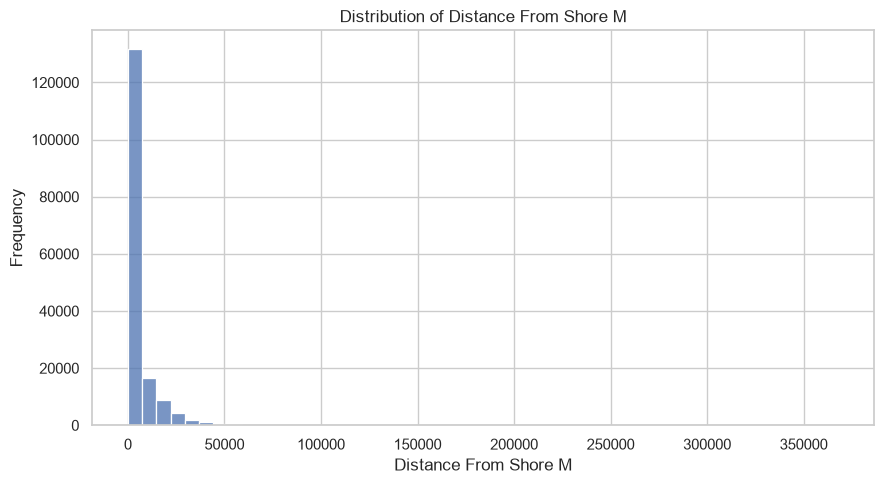

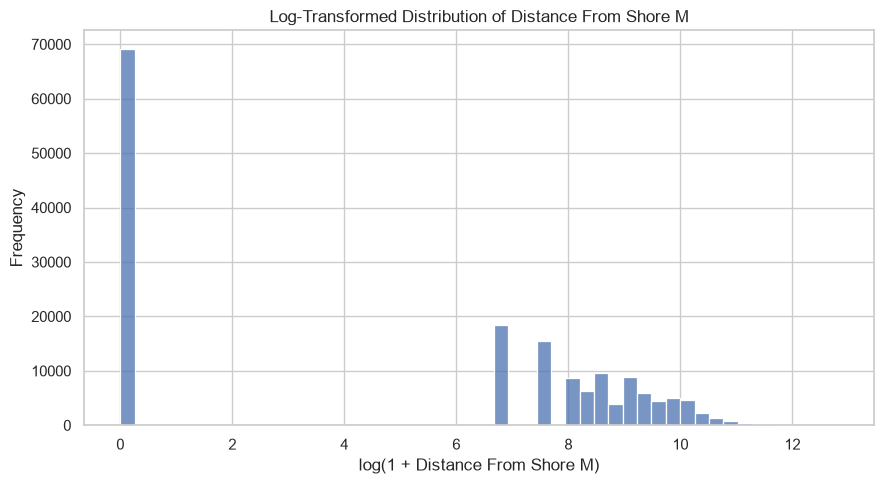

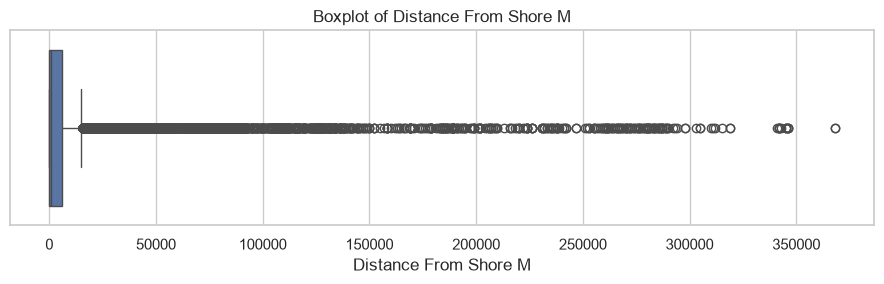


5.1 Numerical Analysis: drift_radius

--- Descriptive Statistics ---


,value
count,"166,481.00"
mean,0.10
median,0.10
standard_deviation,0.04
minimum,0.00
Q1,0.07
Q2,0.10
Q3,0.13
maximum,0.30
IQR,0.06



--- Outlier Detection Comparison ---


,method,threshold,outlier_count,outlier_percentage
0,Standard Z-score,|z| > 3,299,0.18
1,IQR rule,Below Q1 - 1.5×IQR or above Q3 + 1.5×IQR,374,0.22
2,Modified Z-score,|modified z| > 3.5,13,0.01



Distribution interpretation:
The distribution is not strongly skewed, so the mean and median are expected to provide relatively similar descriptions of its center.
The Standard Z-score method is sensitive to non-normality and extreme observations. The IQR and Modified Z-score methods are more robust for skewed distributions. A statistical outlier is not automatically an incorrect observation.


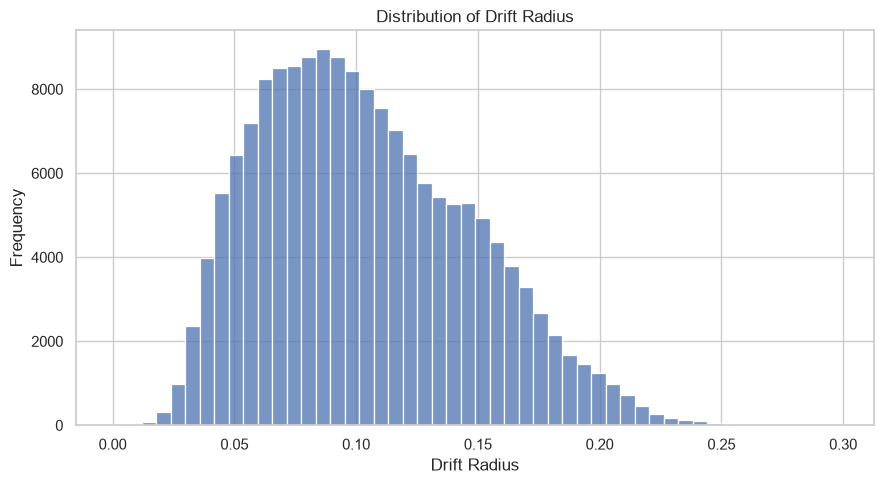

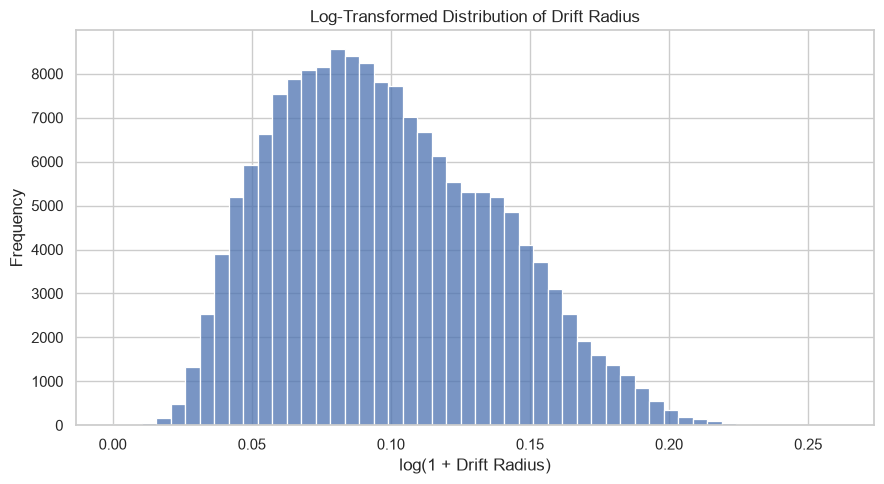

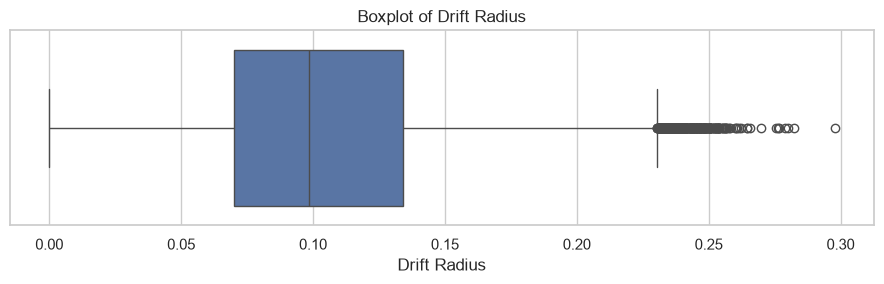


5.2 Categorical Analysis: iso3
Number of unique categories: 180
Most frequent category: CHN
Count: 54,385
Percentage: 32.67%

--- Top 10 Categories ---


,count,percentage
iso3,,
CHN,54385,32.67
USA,11128,6.68
JPN,8513,5.11
NLD,5049,3.03
RUS,4278,2.57
IDN,4160,2.50
DEU,3506,2.11
FRA,3434,2.06
GBR,3408,2.05



Minimum number of categories required to cover at least 80% of the data: 24


,count,percentage,cumulative_percentage
iso3,,,
CHN,54385,32.67,32.67
USA,11128,6.68,39.35
JPN,8513,5.11,44.47
NLD,5049,3.03,47.50
RUS,4278,2.57,50.07
IDN,4160,2.50,52.57
DEU,3506,2.11,54.67
FRA,3434,2.06,56.74
GBR,3408,2.05,58.78



Categories representing less than 0.5% of the data: 146


...


Minimum number of categories required to cover at least 80% of the data: 2


,count,percentage,cumulative_percentage
dock,,,
False,87958,52.83,52.83
True,78523,47.17,100.00



Categories representing less than 0.5% of the data: 0


,count,percentage
dock,,



High-Cardinality Categorical Variables
label: 14,618 unique values (8.78% of rows)
sublabel: 31,151 unique values (18.71% of rows)

The label and sublabel variables contain many unique values. Their rare categories should not be removed automatically because uncommon maritime locations may still contain valid geographical information. For future predictive models, rare labels may be grouped only when there is a justified geographical or operational rule.


In [3]:
# --- SECTION 5: Univariate Analysis ---

# --------------------------------------------------
# 5.1 Numerical Variable Analysis
# --------------------------------------------------
numerical_variables = [
    "distance_from_shore_m",
    "drift_radius",
]


def calculate_numerical_summary(series, variable_name):
    """Calculate descriptive statistics for one numerical variable."""

    clean_series = series.dropna()

    median_value = clean_series.median()
    q1 = clean_series.quantile(0.25)
    q2 = clean_series.quantile(0.50)
    q3 = clean_series.quantile(0.75)
    iqr_value = q3 - q1

    mad_value = np.median(
        np.abs(clean_series - median_value)
    )

    return pd.Series(
        {
            "count": clean_series.count(),
            "mean": clean_series.mean(),
            "median": median_value,
            "standard_deviation": clean_series.std(),
            "minimum": clean_series.min(),
            "Q1": q1,
            "Q2": q2,
            "Q3": q3,
            "maximum": clean_series.max(),
            "IQR": iqr_value,
            "MAD": mad_value,
            "skewness": clean_series.skew(),
        },
        name=variable_name,
    )


def calculate_outlier_summary(series):
    """Detect one-dimensional outliers using three methods."""

    clean_series = series.dropna()

    median_value = clean_series.median()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr_value = q3 - q1

    mad_value = np.median(
        np.abs(clean_series - median_value)
    )

    # Method 1: Standard Z-score
    z_scores = np.abs(
        stats.zscore(
            clean_series,
            nan_policy="omit",
        )
    )

    standard_z_outlier_mask = z_scores > 3
    standard_z_outlier_count = int(
        standard_z_outlier_mask.sum()
    )

    # Method 2: IQR rule
    iqr_lower_bound = q1 - 1.5 * iqr_value
    iqr_upper_bound = q3 + 1.5 * iqr_value

    iqr_outlier_mask = (
        (clean_series < iqr_lower_bound)
        | (clean_series > iqr_upper_bound)
    )

    iqr_outlier_count = int(
        iqr_outlier_mask.sum()
    )

    # Method 3: Modified Z-score based on MAD
    if mad_value == 0:
        modified_z_scores = pd.Series(
            np.zeros(len(clean_series)),
            index=clean_series.index,
        )
    else:
        modified_z_scores = (
            0.6745
            * (clean_series - median_value)
            / mad_value
        )

    modified_z_outlier_mask = (
        modified_z_scores.abs() > 3.5
    )

    modified_z_outlier_count = int(
        modified_z_outlier_mask.sum()
    )

    return pd.DataFrame(
        {
            "method": [
                "Standard Z-score",
                "IQR rule",
                "Modified Z-score",
            ],
            "threshold": [
                "|z| > 3",
                (
                    "Below Q1 - 1.5×IQR or "
                    "above Q3 + 1.5×IQR"
                ),
                "|modified z| > 3.5",
            ],
            "outlier_count": [
                standard_z_outlier_count,
                iqr_outlier_count,
                modified_z_outlier_count,
            ],
            "outlier_percentage": [
                (
                    standard_z_outlier_count
                    / len(clean_series)
                    * 100
                ),
                (
                    iqr_outlier_count
                    / len(clean_series)
                    * 100
                ),
                (
                    modified_z_outlier_count
                    / len(clean_series)
                    * 100
                ),
            ],
        }
    )


for target_numerical in numerical_variables:
    numerical_series = ocean_data[
        target_numerical
    ].dropna()

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"5.1 Numerical Analysis: "
        f"{target_numerical}"
    )

    print(
        "=" * 70
    )

    numerical_summary = (
        calculate_numerical_summary(
            numerical_series,
            target_numerical,
        )
    )

    formatted_numerical_summary = (
        numerical_summary.to_frame("value")
    )

    formatted_numerical_summary["value"] = (
        formatted_numerical_summary["value"]
        .map(lambda value: f"{value:,.2f}")
    )

    print("\n--- Descriptive Statistics ---")
    display(formatted_numerical_summary)

    outlier_summary = (
        calculate_outlier_summary(
            numerical_series
        )
    )

    print("\n--- Outlier Detection Comparison ---")
    display(outlier_summary)

    print(
        "\nDistribution interpretation:"
    )

    if numerical_series.skew() > 1:
        print(
            "The variable is strongly right-skewed. "
            "The mean is influenced by large values, "
            "so the median and MAD provide more robust "
            "measures of center and variability."
        )
    elif numerical_series.skew() < -1:
        print(
            "The variable is strongly left-skewed. "
            "The median and MAD provide more robust "
            "measures than the mean and standard deviation."
        )
    else:
        print(
            "The distribution is not strongly skewed, "
            "so the mean and median are expected to provide "
            "relatively similar descriptions of its center."
        )

    print(
        "The Standard Z-score method is sensitive to "
        "non-normality and extreme observations. The IQR "
        "and Modified Z-score methods are more robust for "
        "skewed distributions. A statistical outlier is not "
        "automatically an incorrect observation."
    )

    # Original-scale histogram
    plt.figure(figsize=(9, 5))

    sns.histplot(
        numerical_series,
        bins=50,
        kde=False,
    )

    readable_title = (
        target_numerical
        .replace("_", " ")
        .title()
    )

    plt.title(
        f"Distribution of {readable_title}"
    )

    plt.xlabel(readable_title)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Log-transformed histogram
    non_negative_series = numerical_series[
        numerical_series >= 0
    ]

    plt.figure(figsize=(9, 5))

    sns.histplot(
        np.log1p(non_negative_series),
        bins=50,
        kde=False,
    )

    plt.title(
        f"Log-Transformed Distribution of "
        f"{readable_title}"
    )

    plt.xlabel(
        f"log(1 + {readable_title})"
    )

    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(9, 3))

    sns.boxplot(
        x=numerical_series,
    )

    plt.title(
        f"Boxplot of {readable_title}"
    )

    plt.xlabel(readable_title)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 5.2 Categorical Variable Analysis
# --------------------------------------------------
categorical_variables = [
    "iso3",
    "label_source",
    "dock",
]

top_k = 10
target_coverage_percentage = 80
rare_category_threshold_percentage = 0.5


def analyze_categorical_variable(
    data,
    variable_name,
    top_k_value=10,
    coverage_percentage=80,
    rare_threshold_percentage=0.5,
):
    """Analyze frequencies and cardinality of one categorical variable."""

    categorical_series = (
        data[variable_name]
        .astype("string")
        .fillna("Missing")
    )

    category_counts = (
        categorical_series.value_counts(
            dropna=False
        )
    )

    category_percentages = (
        categorical_series.value_counts(
            normalize=True,
            dropna=False,
        )
        * 100
    )

    frequency_table = pd.DataFrame(
        {
            "count": category_counts,
            "percentage": category_percentages,
        }
    )

    cumulative_percentage = (
        category_percentages.cumsum()
    )

    categories_needed_for_coverage = int(
        (
            cumulative_percentage
            < coverage_percentage
        ).sum()
        + 1
    )

    coverage_categories = frequency_table.head(
        categories_needed_for_coverage
    ).copy()

    coverage_categories[
        "cumulative_percentage"
    ] = (
        coverage_categories[
            "percentage"
        ].cumsum()
    )

    rare_categories = frequency_table[
        frequency_table["percentage"]
        < rare_threshold_percentage
    ]

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"5.2 Categorical Analysis: "
        f"{variable_name}"
    )

    print(
        "=" * 70
    )

    print(
        f"Number of unique categories: "
        f"{categorical_series.nunique(dropna=False):,}"
    )

    print(
        f"Most frequent category: "
        f"{category_counts.index[0]}"
    )

    print(
        f"Count: "
        f"{category_counts.iloc[0]:,}"
    )

    print(
        f"Percentage: "
        f"{category_percentages.iloc[0]:.2f}%"
    )

    print(
        f"\n--- Top {top_k_value} Categories ---"
    )

    display(
        frequency_table.head(top_k_value)
    )

    print(
        "\nMinimum number of categories required "
        f"to cover at least {coverage_percentage}% "
        f"of the data: "
        f"{categories_needed_for_coverage}"
    )

    display(coverage_categories)

    print(
        "\nCategories representing less than "
        f"{rare_threshold_percentage}% "
        f"of the data: {len(rare_categories)}"
    )

    display(rare_categories)

    return frequency_table


categorical_frequency_tables = {}

for target_categorical in categorical_variables:
    categorical_frequency_tables[
        target_categorical
    ] = analyze_categorical_variable(
        data=ocean_data,
        variable_name=target_categorical,
        top_k_value=top_k,
        coverage_percentage=target_coverage_percentage,
        rare_threshold_percentage=(
            rare_category_threshold_percentage
        ),
    )


# High-cardinality categorical variables
print(
    "\n"
    + "=" * 70
)

print(
    "High-Cardinality Categorical Variables"
)

print(
    "=" * 70
)

for high_cardinality_variable in [
    "label",
    "sublabel",
]:
    unique_count = ocean_data[
        high_cardinality_variable
    ].nunique(dropna=False)

    unique_percentage = (
        unique_count
        / len(ocean_data)
        * 100
    )

    print(
        f"{high_cardinality_variable}: "
        f"{unique_count:,} unique values "
        f"({unique_percentage:.2f}% of rows)"
    )

print(
    "\nThe label and sublabel variables contain many unique "
    "values. Their rare categories should not be removed "
    "automatically because uncommon maritime locations may "
    "still contain valid geographical information. For future "
    "predictive models, rare labels may be grouped only when "
    "there is a justified geographical or operational rule."
)

--- 6.1.1 Pearson Correlation Matrix ---
                        lat   lon  distance_from_shore_m  drift_radius
lat                    1.00 -0.08                  -0.12         -0.15
lon                   -0.08  1.00                  -0.03          0.17
distance_from_shore_m -0.12 -0.03                   1.00          0.28
drift_radius          -0.15  0.17                   0.28          1.00

--- 6.1.2 Spearman Rank Correlation Matrix ---
                        lat   lon  distance_from_shore_m  drift_radius
lat                    1.00 -0.14                  -0.19         -0.18
lon                   -0.14  1.00                   0.13          0.17
distance_from_shore_m -0.19  0.13                   1.00          0.54
drift_radius          -0.18  0.17                   0.54          1.00

--- 6.1.3 Kendall's Tau Correlation Matrix ---
                        lat   lon  distance_from_shore_m  drift_radius
lat                    1.00 -0.08                  -0.14         -0.12
lon        

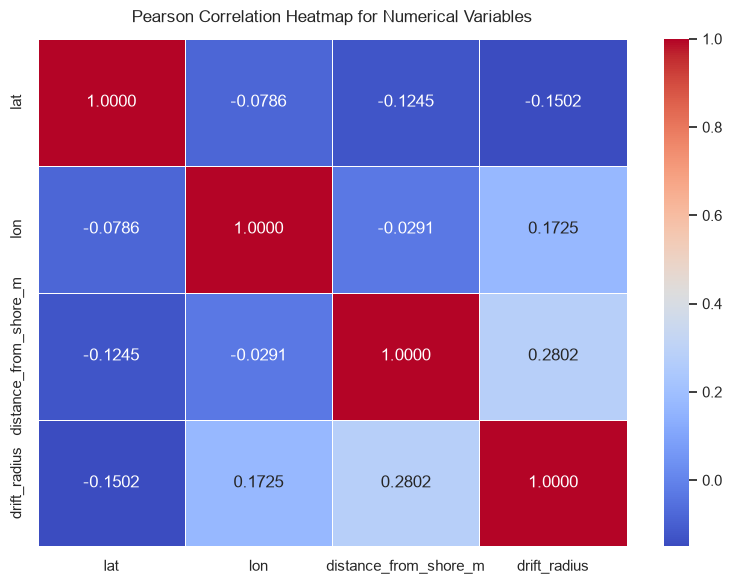

In [4]:
# Create a cleaned dataset for correlation analysis
clean_ocean = ocean_data.dropna(
    subset=[
        "distance_from_shore_m",
        "drift_radius",
        "lat",
        "lon",
    ]
).copy()
numeric_features = ['lat', 'lon', 'distance_from_shore_m', 'drift_radius']
clean_numeric_data = clean_ocean[numeric_features].dropna()

# Calculate matrices for all three statistical methods required
pearson_corr = clean_numeric_data.corr(method='pearson')
spearman_corr = clean_numeric_data.corr(method='spearman')
kendall_corr = clean_numeric_data.corr(method='kendall')

print("--- 6.1.1 Pearson Correlation Matrix ---")
print(pearson_corr.round(4))
print("\n--- 6.1.2 Spearman Rank Correlation Matrix ---")
print(spearman_corr.round(4))
print("\n--- 6.1.3 Kendall's Tau Correlation Matrix ---")
print(kendall_corr.round(4))

# --- 8. Heatmap: Pearson Linear Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title(
    "Pearson Correlation Heatmap for Numerical Variables",
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.savefig("pearson_correlation_heatmap.png")
plt.show()

In [5]:
print("--- 6.2.1 Cross-Tabulation: Top Country Codes (iso3) vs. Dock Flag ---")
dock_country_cross = pd.crosstab(clean_ocean['iso3'], clean_ocean['dock'], margins=True).loc[['CHN', 'USA', 'JPN', 'All']]
print(dock_country_cross)

print("\n--- 6.2.2 Binning and Frequency Cross-Tabulation: Shoreline Distance Categories vs. Country Code ---")
# Create shoreline-distance categories using equal engineering thresholds
clean_ocean['distance_bins'] = pd.cut(clean_ocean['distance_from_shore_m'], 
                                      bins=[-1, 500, 2000, 10000, float('inf')], 
                                      labels=['Ultra-Close (<500m)', 'Near-Coastal (500m-2km)', 'Mid-Shore (2km-10km)', 'Deep-Ocean (>10km)'])

# Generating the binned cross-tabulation table against dominant country codes
binned_cross_table = pd.crosstab(clean_ocean['distance_bins'], clean_ocean['iso3'], normalize='columns') * 100
print(binned_cross_table[['CHN', 'USA', 'JPN']].round(2))

--- 6.2.1 Cross-Tabulation: Top Country Codes (iso3) vs. Dock Flag ---
dock  False   True     All
iso3                      
CHN   29602  24783   54385
USA    2727   8401   11128
JPN    5575   2938    8513
All   87958  78523  166481

--- 6.2.2 Binning and Frequency Cross-Tabulation: Shoreline Distance Categories vs. Country Code ---
iso3                      CHN   USA   JPN
distance_bins                            
Ultra-Close (<500m)     42.12 69.73 25.87
Near-Coastal (500m-2km) 18.91 13.04 33.08
Mid-Shore (2km-10km)    19.93  4.71 40.10
Deep-Ocean (>10km)      19.03 12.52  0.95


## 6. Correlations and Relationships (20%)

### 6.1 Numerical-to-Numerical Relationships

Pearson, Spearman, and Kendall correlations were calculated for the numerical variables.

- **Pearson correlation** measures the strength of a linear relationship.
- **Spearman correlation** measures whether two variables follow a monotonic relationship based on their ranks.
- **Kendall correlation** also measures rank association and is generally more conservative than Spearman's coefficient.

The relationship between `distance_from_shore_m` and `drift_radius` differs across the three methods:

- Pearson correlation: approximately **0.28**
- Spearman correlation: approximately **0.54**
- Kendall correlation: approximately **0.41**

The stronger rank-based correlations suggest that the variables tend to increase together, but the relationship is not purely linear. Skewness, repeated values, and extreme observations may reduce the Pearson coefficient.

The relationship should be interpreted as moderate rather than as proof of a strong causal connection.

### 6.2 Categorical and Binned Relationships

The cross-tabulation between `iso3` and `dock` shows clear differences between the selected countries:

- China contains both dock and non-dock records in relatively similar proportions.
- The United States contains substantially more `dock=True` records than `dock=False` records.
- Japan contains more `dock=False` records than `dock=True` records.

The binned shoreline-distance table also reveals different spatial distributions:

- **China:** 42.12% of records are within 500 meters of shore.
- **United States:** 69.73% of records are within 500 meters of shore.
- **Japan:** only 25.87% are within 500 meters, while 40.10% are between 2 and 10 kilometers from shore.
- Only 0.95% of the Japanese records are more than 10 kilometers from shore.

These results indicate that shoreline-distance distributions differ between countries. However, they do not prove that national infrastructure or management policies caused those differences. Dataset coverage, source conventions, geography, and classification practices may also contribute.

### 6.3 Graphical Insights

#### Histogram

The histogram shows that `distance_from_shore_m` is strongly right-skewed. Most observations are close to the shoreline, while a smaller number extend to much larger distances.

The displayed histogram is limited to distances of 25 kilometers or less to make the main distribution visible. This filtering affects only the visualization and not the main statistical calculations.

#### Scatterplot

The scatterplot suggests a positive but highly dispersed relationship between distance from shore and drift radius. The points do not form a narrow straight-line pattern, which is consistent with the difference between Pearson and rank-based correlations.

#### Bar Chart

The bar chart demonstrates substantial country imbalance. China contains far more observations than the other most frequent country codes.

#### Boxplot and Violin Plot

The boxplot and violin plot show that the three selected countries have different shoreline-distance distributions. Because the variable is highly skewed, the median, IQR, and distribution shape are more informative than the mean alone.

#### Pie Chart

The pie chart summarizes the five most frequent label sources. It shows that the dataset depends more heavily on certain source categories than others, which may introduce source-related bias.

#### Pairplot

The pairplot compares the numerical variables across label sources. It highlights differences in geographical coverage and distribution shape, but visual clustering should not be interpreted as evidence of causation.

#### Heatmap

The heatmap provides an overview of linear correlations. Most numerical relationships are weak, with the largest Pearson association occurring between distance from shore and drift radius.

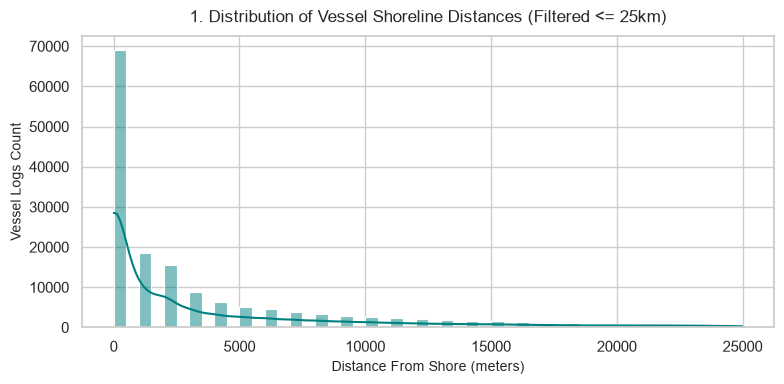

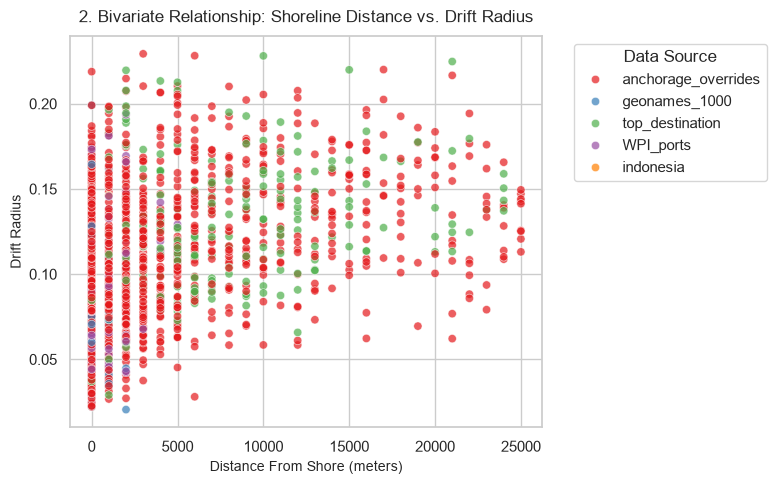

C:\Users\Elior\AppData\Local\Temp\ipykernel_11984\2983748806.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_countries.index, y=top_5_countries.values, palette='viridis')


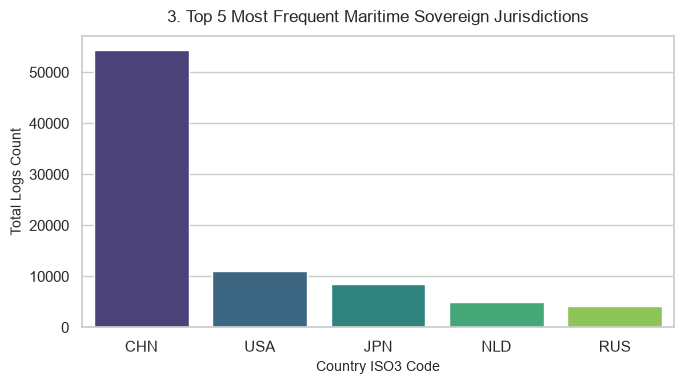

C:\Users\Elior\AppData\Local\Temp\ipykernel_11984\2983748806.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_3_countries_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[0])
C:\Users\Elior\AppData\Local\Temp\ipykernel_11984\2983748806.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top_3_countries_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[1])


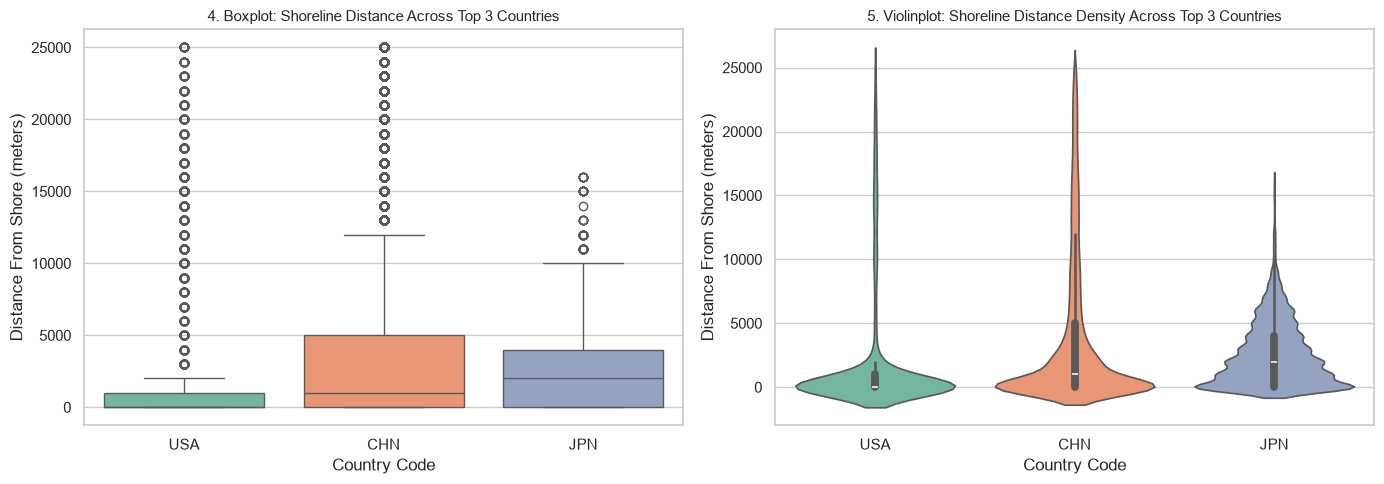

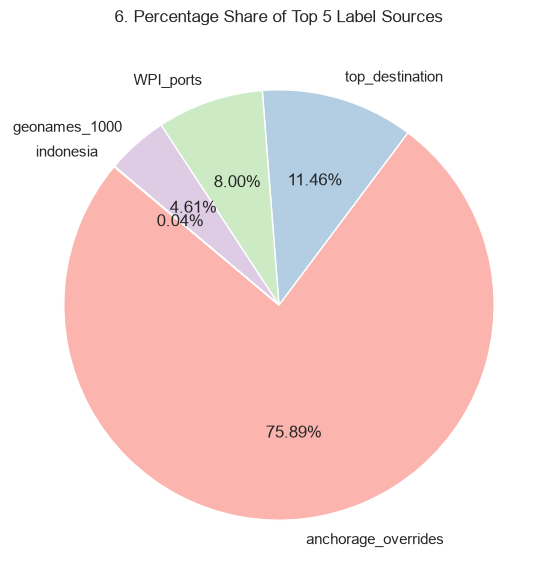

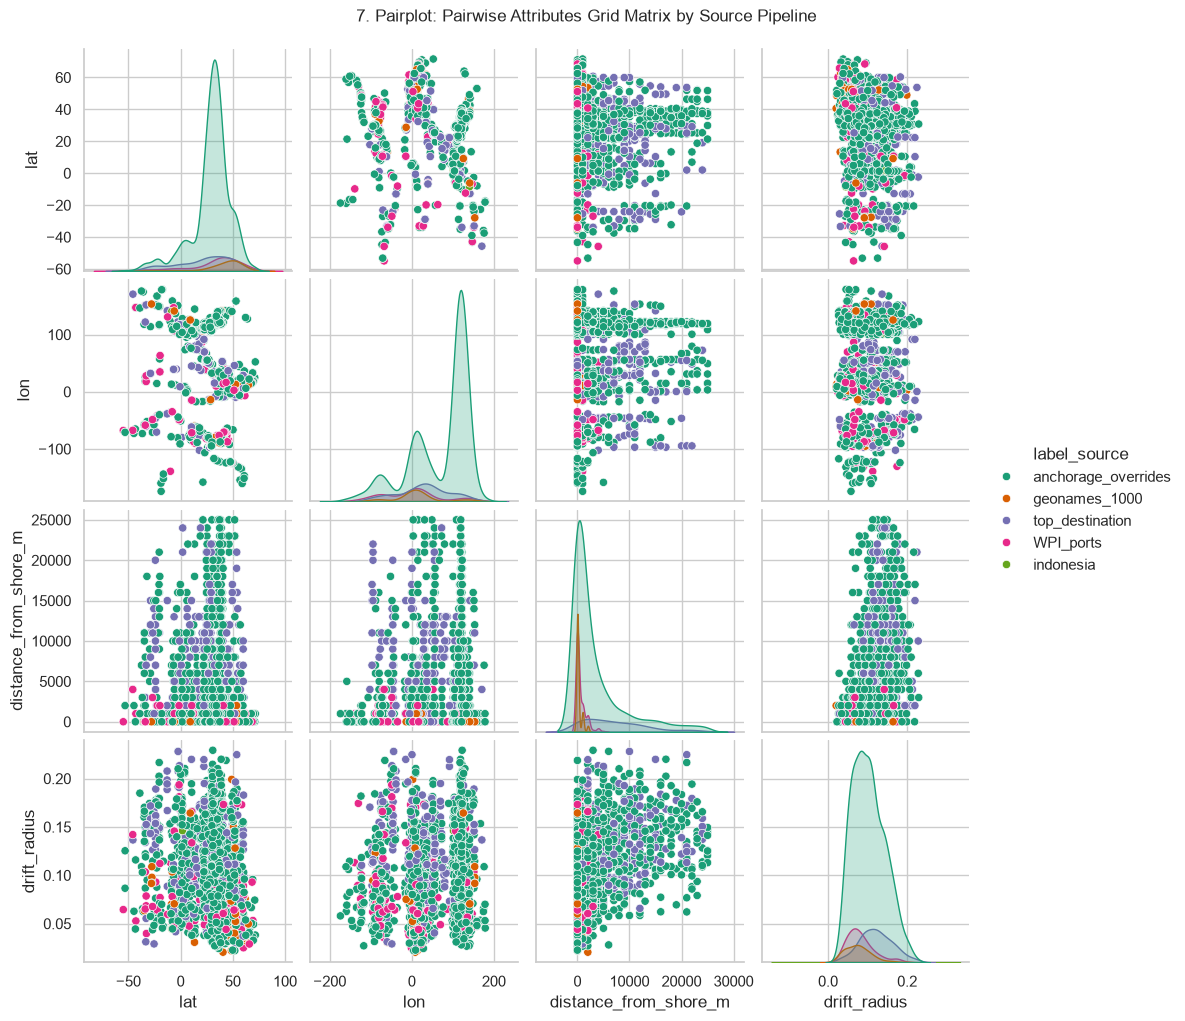

In [6]:
# Clean data by removing rows with missing coordinates or distances
clean_ocean = ocean_data.dropna(subset=['distance_from_shore_m', 'drift_radius', 'lat', 'lon']).copy()

# Filter out extreme outliers for continuous variables to ensure readable graph layouts
plot_data_filtered = clean_ocean[clean_ocean['distance_from_shore_m'] <= 25000]

# Take a random statistical sample of 2,000 rows for complex plots to optimize rendering performance
sample_data = plot_data_filtered.sample(n=2000, random_state=42)

# --- 1. Histogram: Distribution of Shoreline Distances ---
plt.figure(figsize=(8, 4))
sns.histplot(data=plot_data_filtered, x='distance_from_shore_m', bins=50, kde=True, color='teal')
plt.title('1. Distribution of Vessel Shoreline Distances (Filtered <= 25km)', fontsize=12, pad=10)
plt.xlabel('Distance From Shore (meters)', fontsize=10)
plt.ylabel('Vessel Logs Count', fontsize=10)
plt.tight_layout()
plt.savefig('shore_distance_histogram.png')
plt.show()

# --- 2. Scatterplot: Distance from Shore vs. Drift Radius ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_data, x='distance_from_shore_m', y='drift_radius', hue='label_source', alpha=0.7, palette='Set1')
plt.title('2. Bivariate Relationship: Shoreline Distance vs. Drift Radius', fontsize=12, pad=10)
plt.xlabel('Distance From Shore (meters)', fontsize=10)
plt.ylabel('Drift Radius', fontsize=10)
plt.legend(title='Data Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('distance_vs_drift_scatter.png')
plt.show()

# --- 3. Barchart: Top 5 Most Frequent Countries ---
plt.figure(figsize=(7, 4))
top_5_countries = clean_ocean['iso3'].value_counts().head(5)
sns.barplot(x=top_5_countries.index, y=top_5_countries.values, palette='viridis')
plt.title('3. Top 5 Most Frequent Maritime Sovereign Jurisdictions', fontsize=12, pad=10)
plt.xlabel('Country ISO3 Code', fontsize=10)
plt.ylabel('Total Logs Count', fontsize=10)
plt.tight_layout()
plt.savefig('top_countries_barchart.png')
plt.show()

# --- 4. Boxplot & 5. Violinplot: Shoreline Distance by Top 3 Countries ---
top_3_countries_data = plot_data_filtered[plot_data_filtered['iso3'].isin(['CHN', 'USA', 'JPN'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=top_3_countries_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[0])
axes[0].set_title('4. Boxplot: Shoreline Distance Across Top 3 Countries', fontsize=11)
axes[0].set_xlabel('Country Code')
axes[0].set_ylabel('Distance From Shore (meters)')

sns.violinplot(data=top_3_countries_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[1])
axes[1].set_title('5. Violinplot: Shoreline Distance Density Across Top 3 Countries', fontsize=11)
axes[1].set_xlabel('Country Code')
axes[1].set_ylabel('Distance From Shore (meters)')
plt.tight_layout()
plt.savefig('box_violin_combined.png')
plt.show()

# --- 6. Piechart: Share of Top 5 Label Sources ---
plt.figure(figsize=(6, 6))
label_counts = clean_ocean['label_source'].value_counts().head(5)
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.2f%%', startangle=140, colors=sns.color_palette('Pastel1'))
plt.title('6. Percentage Share of Top 5 Label Sources', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('label_sources_piechart.png')
plt.show()

# --- 7. Pairplot: Pairwise Relationships of Numeric Core Attributes ---
pp = sns.pairplot(sample_data[['lat', 'lon', 'distance_from_shore_m', 'drift_radius', 'label_source']], hue='label_source', palette='Dark2')
pp.fig.suptitle('7. Pairplot: Pairwise Attributes Grid Matrix by Source Pipeline', y=1.02, fontsize=12)
plt.savefig('numeric_pairwise_grid.png')
plt.show()

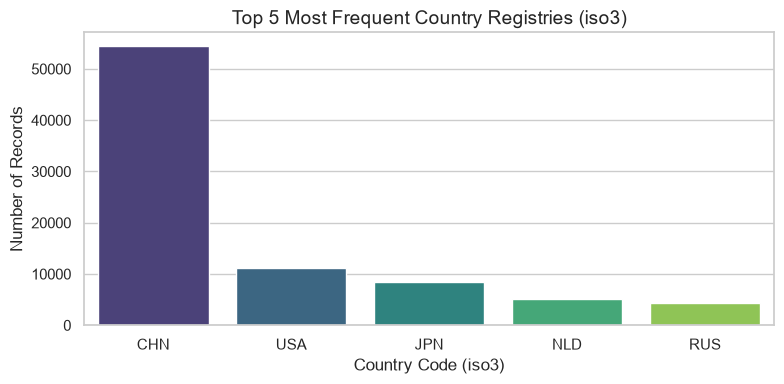

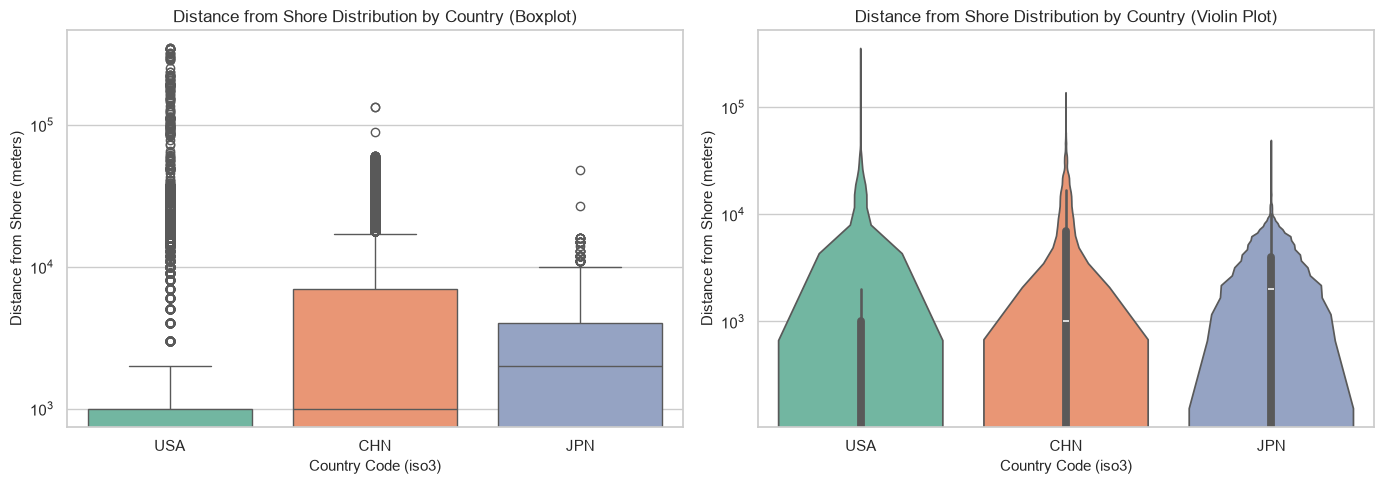

In [7]:
# --- SECTION 6.3: Informative Visualizations ---

# 1. Bar Chart for Top 5 Countries (iso3)
top_5_countries = ocean_data['iso3'].value_counts().head(5)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_5_countries.index, y=top_5_countries.values, palette='viridis', hue=top_5_countries.index, legend=False)
plt.title('Top 5 Most Frequent Country Registries (iso3)', fontsize=14)
plt.xlabel('Country Code (iso3)', fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.tight_layout()
plt.show()

# Filter data for top 3 countries to analyze shore distance distribution
top_3_data = ocean_data[ocean_data['iso3'].isin(['CHN', 'USA', 'JPN'])]

# 2. Boxplot & Violin Plot with Log Scale for Right-Skewed Data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot with log scale
sns.boxplot(data=top_3_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[0], hue='iso3', legend=False)
axes[0].set_yscale('log')
axes[0].set_title(
    "Distance from Shore Distribution by Country (Boxplot)",
    fontsize=12,
)
axes[0].set_xlabel('Country Code (iso3)', fontsize=11)
axes[0].set_ylabel(
    "Distance from Shore (meters)",
    fontsize=11,
)

# Violin Plot with log scale
sns.violinplot(data=top_3_data, x='iso3', y='distance_from_shore_m', palette='Set2', ax=axes[1], hue='iso3', legend=False)
axes[1].set_yscale('log')
axes[1].set_title(
    "Distance from Shore Distribution by Country (Violin Plot)",
    fontsize=12,
)
axes[1].set_xlabel('Country Code (iso3)', fontsize=11)
axes[1].set_ylabel(
    "Distance from Shore (meters)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [8]:
# --- SECTION 7: Index Analysis ---

index_summary = pd.Series(
    {
        "index_type": type(ocean_data.index).__name__,
        "number_of_index_values": len(ocean_data.index),
        "is_unique": ocean_data.index.is_unique,
        "contains_duplicates": ocean_data.index.has_duplicates,
        "is_monotonically_increasing": (
            ocean_data.index.is_monotonic_increasing
        ),
        "is_monotonically_decreasing": (
            ocean_data.index.is_monotonic_decreasing
        ),
        "is_time_based": isinstance(
            ocean_data.index,
            pd.DatetimeIndex,
        ),
        "minimum_index_value": ocean_data.index.min(),
        "maximum_index_value": ocean_data.index.max(),
    },
    name="index_analysis",
)

display(index_summary.to_frame("result"))

,result
index_type,Index
number_of_index_values,166481
is_unique,True
contains_duplicates,False
is_monotonically_increasing,True
is_monotonically_decreasing,False
is_time_based,False
minimum_index_value,0
maximum_index_value,166481


## 7. Index Analysis Discussion (5%)

The DataFrame uses a default integer `RangeIndex`.

- The index is unique.
- It contains no duplicated index values.
- It is monotonically increasing and therefore sorted by its own integer values.
- It is not based on time.
- It does not provide semantic information about the maritime records.
- It represents the current row order created when the CSV file was loaded.

The fact that the index is sorted does not prove that the data itself is geographically, alphabetically, or chronologically sorted. No chronological analysis can be performed because neither the index nor the dataset columns contain timestamps.

The analyses above are therefore independent of a temporal index. To perform time-based analysis, the dataset would require a trustworthy date or timestamp attribute.

## 8. Insights and Story of the Data (15%)

### 8.1 Key Insights

#### Insight 1: Most locations are relatively close to the shoreline

The distribution of `distance_from_shore_m` is strongly right-skewed. Most observations are concentrated near the coast, while a smaller number of records extend much farther from shore. This explains why the mean is substantially larger than the median and why robust measures are more representative.

#### Insight 2: The geographical coverage is highly imbalanced

The `iso3` frequency distribution is dominated by a limited number of country codes. A relatively small subset of countries represents most of the dataset, while many countries occur rarely. Therefore, the dataset should not be interpreted as a geographically balanced representation of global maritime locations.

#### Insight 3: Distance from shore and drift radius are related, but not purely linearly

The Pearson, Spearman, and Kendall correlations do not produce identical values. The stronger rank-based association suggests that the relationship between `distance_from_shore_m` and `drift_radius` is monotonic but may be non-linear and influenced by extreme observations.

### 8.2 Biases and Risks

A major limitation is geographical coverage bias. Countries with more mapped anchorages or more complete source coverage may be overrepresented.

Additional risks include:

- Missing values concentrated in selected descriptive and numerical fields.
- Unknown documentation regarding the exact measurement or calculation process.
- Dependence on externally assigned labels and administrative country codes.
- Lack of temporal attributes.
- Lack of a verified creation date.
- Potential differences between label sources.

### 8.3 Engineering and Statistical Failure Points

1. **Mixed data types:** The original `dock` column requires normalization before Boolean operations or model input.
2. **Extreme skewness:** Models based directly on untransformed distance values may be strongly influenced by the long right tail.
3. **High-cardinality identifiers:** `s2id` should not be passed directly into a model as an ordinary categorical variable without appropriate processing.
4. **Imbalanced countries:** A model may learn the behavior of dominant countries while performing poorly for rare countries.
5. **Imputed measurements:** Imputed numerical values must not be interpreted as original observations.
6. **No temporal validation:** The dataset cannot support conclusions about seasonal changes, historical trends, or current maritime conditions.

### 8.4 What Was Learned

The analysis changed the initial interpretation of the table. At first, the dataset may appear to be a straightforward global maritime activity dataset. However, the EDA shows that it is better understood as an imbalanced geographical reference table of maritime anchorage locations.

The analysis also demonstrates that data completeness alone does not guarantee representativeness. Even though the dataset contains relatively few missing values and no full duplicate rows, geographical imbalance, uncertain source definitions, and the absence of time information still limit the conclusions that can be drawn.

In [9]:
# --- SECTION 9: Bonus Analysis ---

# --------------------------------------------------
# 9.1 Feature Engineering
# --------------------------------------------------
bonus_data = ocean_data.dropna(
    subset=[
        "distance_from_shore_m",
        "drift_radius",
        "iso3",
    ]
).copy()

# Avoid unstable ratios caused by zero or near-zero drift-radius values
minimum_valid_drift_radius = 0.001

safe_drift_radius = bonus_data["drift_radius"].where(
    bonus_data["drift_radius"] >= minimum_valid_drift_radius,
    np.nan,
)

bonus_data["distance_to_drift_ratio"] = (
    bonus_data["distance_from_shore_m"]
    / safe_drift_radius
)

print("--- 9.1 Engineered Feature Summary ---")

ratio_summary = (
    bonus_data[
        bonus_data["iso3"].isin(["CHN", "USA", "JPN"])
    ]
    .groupby("iso3")["distance_to_drift_ratio"]
    .agg(["count", "median", "mean", "std"])
)

formatted_ratio_summary = ratio_summary.copy()

formatted_ratio_summary["count"] = (
    formatted_ratio_summary["count"]
    .map(lambda value: f"{int(value):,}")
)

for column_name in ["median", "mean", "std"]:
    formatted_ratio_summary[column_name] = (
        formatted_ratio_summary[column_name]
        .map(lambda value: f"{value:,.2f}")
    )

display(formatted_ratio_summary)

# --------------------------------------------------
# 9.2 Hypothesis Testing
# --------------------------------------------------
china_distances = bonus_data.loc[
    bonus_data["iso3"] == "CHN",
    "distance_from_shore_m",
]

usa_distances = bonus_data.loc[
    bonus_data["iso3"] == "USA",
    "distance_from_shore_m",
]

# Welch's t-test does not assume equal population variances
t_statistic, p_value = stats.ttest_ind(
    china_distances,
    usa_distances,
    equal_var=False,
    nan_policy="omit",
)

alpha = 0.05

print("\n--- 9.2 Welch's Independent-Samples T-Test ---")
print("Null hypothesis: The population means are equal.")
print("Alternative hypothesis: The population means are different.")
print(f"China sample size: {len(china_distances):,}")
print(f"USA sample size: {len(usa_distances):,}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6e}")
print(f"Significance level: {alpha}")

if p_value < alpha:
    print(
        "Decision: Reject the null hypothesis at the 5% "
        "significance level."
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis at "
        "the 5% significance level."
    )

print(
    "\nImportant: Statistical significance does not measure "
    "the size or practical importance of the difference."
)

# Report effect size using Cohen's d
china_variance = china_distances.var(ddof=1)
usa_variance = usa_distances.var(ddof=1)

pooled_standard_deviation = np.sqrt(
    (
        (len(china_distances) - 1) * china_variance
        + (len(usa_distances) - 1) * usa_variance
    )
    / (
        len(china_distances)
        + len(usa_distances)
        - 2
    )
)

cohens_d = (
    china_distances.mean()
    - usa_distances.mean()
) / pooled_standard_deviation

print(f"Cohen's d effect size: {cohens_d:.4f}")

--- 9.1 Engineered Feature Summary ---


,count,median,mean,std
iso3,,,,
CHN,"54,382","12,485.97","40,035.57","65,680.65"
JPN,"8,512","25,139.07","32,734.93","150,112.00"
USA,"11,128",0.00,"40,171.54","169,496.33"



--- 9.2 Welch's Independent-Samples T-Test ---
Null hypothesis: The population means are equal.
Alternative hypothesis: The population means are different.
China sample size: 54,385
USA sample size: 11,128
T-statistic: 3.8844
P-value: 1.031262e-04
Significance level: 0.05
Decision: Reject the null hypothesis at the 5% significance level.

Important: Statistical significance does not measure the size or practical importance of the difference.
Cohen's d effect size: 0.0652


### 9.1 Feature Engineering Discussion

The engineered variable `distance_to_drift_ratio` compares the distance from shore with the reported drift radius.

This feature may help distinguish locations that are far from shore relative to their local spatial radius. However, its practical meaning depends on the exact definition and measurement units of `drift_radius`, which are not fully documented in the CSV file.

Rows with a zero drift radius were assigned a missing ratio rather than an artificially inflated value, because division by zero does not produce a meaningful result.

### 9.2 Hypothesis-Test Discussion

Welch's independent-samples t-test was used to test whether the mean `distance_from_shore_m` differs between the observations associated with China and the United States.

- The null hypothesis states that the two population means are equal.
- The alternative hypothesis states that the means differ.
- Welch's test was selected because it does not require equal variances.

A p-value below 0.05 provides evidence against the null hypothesis. However, it does not prove that country identity causes the difference. It also does not indicate whether the difference is practically important.

Because the dataset contains very large groups, even a small difference may become statistically significant. Cohen's d is therefore reported as an effect-size measure alongside the p-value.

### 9.3 Proposed Future Research

1. **Temporal enrichment:** Add reliable timestamps to examine seasonality and changes over time.
2. **Environmental enrichment:** Merge wind, current, weather, water-depth, and bathymetry data.
3. **Source comparison:** Compare distributions between different `label_source` categories.
4. **Geographical validation:** Evaluate whether country imbalance reflects real anchorage availability or unequal source coverage.
5. **Robust group comparison:** Apply a non-parametric test, such as the Mann–Whitney U test, because the distance distributions are strongly skewed.